breast-w

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_curve, auc, precision_recall_curve, average_precision_score,
                             mean_squared_error, mean_absolute_error, r2_score, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

DATASET_NAME = "breast-w"

1. (1 балл) Загрузите предложенный вам датасет с помощью функции `sklearn.datasets.fetch_openml`. Выведите текстовое описание загруженного датасета. Определите какая бизнес-задача ставится. Переведите бизнес-задачу в задачу машинного обучения.

In [7]:
def load_and_describe(dataset_name):
    try:
        data = fetch_openml(data_id=dataset_name, as_frame=True, parser='auto')
    except:
        data = fetch_openml(name=dataset_name, as_frame=True, parser='auto')

    df = data.frame
    print("ОПИСАНИЕ ДАТАСЕТА")
    print(f"Название: {data.details.get('name', 'Неизвестно')}")
    print(f"Описание: {data.details.get('description', 'Нет описания')[:500]}")
    print(f"Количество строк: {df.shape[0]}, столбцов: {df.shape[1]}")
    print(f"Целевой признак: {data.target_names if hasattr(data, 'target_names') else 'unknown'}")

    target_col = data.target_names[0] if hasattr(data, 'target_names') else 'class'
    unique_targets = df[target_col].nunique()

    if unique_targets <= 10:
        task_type = "классификация"
        n_classes = unique_targets
    else:
        task_type = "регрессия"
        n_classes = None

    print(f"\nБИЗНЕС-ЗАДАЧА")
    print(f"На основе описания датасета бизнес-задача: предсказание значения '{target_col}'")
    print(f"Перевод в задачу МО: это задача {task_type} с {unique_targets} уникальными значениями целевой переменной.")

    return data, df, task_type, target_col

data, df, TASK_TYPE, TARGET_COL = load_and_describe(DATASET_NAME)
print(f"\nОпределенный тип задачи: {TASK_TYPE}")

ОПИСАНИЕ ДАТАСЕТА
Название: breast-w
Описание: Нет описания
Количество строк: 699, столбцов: 10
Целевой признак: ['Class']

БИЗНЕС-ЗАДАЧА
На основе описания датасета бизнес-задача: предсказание значения 'Class'
Перевод в задачу МО: это задача классификация с 2 уникальными значениями целевой переменной.

Определенный тип задачи: классификация


В датасете breast-w имеется 699 строк и 10 столбцов. Данный датасет относится к задаче классификации с двумя уникальными значениями целевой переменной(бинарная классификация0. Бизнес-задачей является предсказание значения 'Class'.

2. (1 балл) Проведите предварительный анализ датасета.  Выведите основную статистическую информацию о данных. Проверьте дисбаланс целевого признака.

СТАТИСТИЧЕСКАЯ ИНФОРМАЦИЯ
Типы данных:
Clump_Thickness             int64
Cell_Size_Uniformity        int64
Cell_Shape_Uniformity       int64
Marginal_Adhesion           int64
Single_Epi_Cell_Size        int64
Bare_Nuclei               float64
Bland_Chromatin             int64
Normal_Nucleoli             int64
Mitoses                     int64
Class                    category
dtype: object

Основные статистики:
       Clump_Thickness  Cell_Size_Uniformity  Cell_Shape_Uniformity  \
count       699.000000            699.000000             699.000000   
mean          4.417740              3.134478               3.207439   
std           2.815741              3.051459               2.971913   
min           1.000000              1.000000               1.000000   
25%           2.000000              1.000000               1.000000   
50%           4.000000              1.000000               1.000000   
75%           6.000000              5.000000               5.000000   
max          10.0

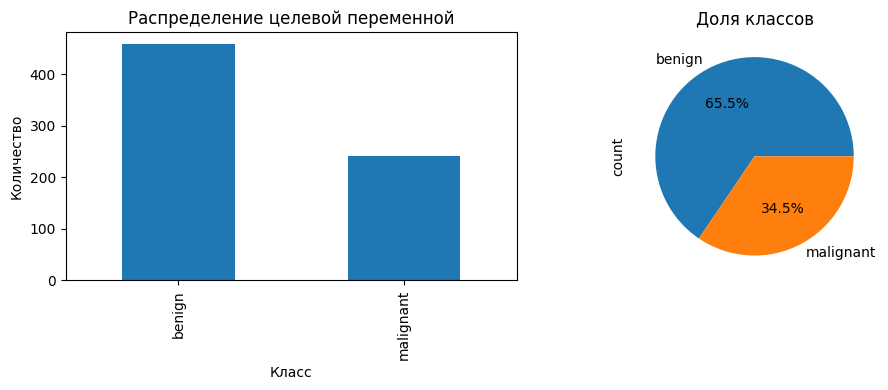

In [8]:
def exploratory_analysis(df, target_col, task_type):
    print("СТАТИСТИЧЕСКАЯ ИНФОРМАЦИЯ")
    print(f"Типы данных:\n{df.dtypes}")
    print(f"\nОсновные статистики:\n{df.describe()}")

    print(f"\nПРОВЕРКА ДИСБАЛАНСА ЦЕЛЕВОГО ПРИЗНАКА")
    target_counts = df[target_col].value_counts()
    print(f"Распределение целевой переменной:\n{target_counts}")

    if task_type == "классификация":
        imbalance_ratio = target_counts.max() / target_counts.min()
        if imbalance_ratio > 3:
            print(f"ДИСБАЛАНС: Соотношение классов {imbalance_ratio:.2f}:1")
        else:
            print(f"Баланс классов приемлемый (соотношение {imbalance_ratio:.2f}:1)")

    if task_type == "классификация" and df[target_col].nunique() <= 20:
        plt.figure(figsize=(10,4))
        plt.subplot(1,2,1)
        df[target_col].value_counts().plot(kind='bar')
        plt.title('Распределение целевой переменной')
        plt.xlabel('Класс')
        plt.ylabel('Количество')

        plt.subplot(1,2,2)
        df[target_col].value_counts().plot(kind='pie', autopct='%1.1f%%')
        plt.title('Доля классов')
        plt.tight_layout()
        plt.show()

exploratory_analysis(df, TARGET_COL, TASK_TYPE)

По выводам мы видим, что не все значения являются числовыми, что требуется изменить для дальнейшего обучения модели. Баланс классов приемлем, не наблюдается дисбаланса. Обучение получится хорошо, с таким соотношением.

3. (1 балл) Убедитесь, что данные пригодны для моделирования. В данных не должно быть пропущенных значений, все признаки должны быть численными. Если эти условия нарушаются, исправьте это.

In [10]:
def clean_data(df, target_col):
    df_clean = df.copy()

    print("ПРОВЕРКА ПРОПУСКОВ")
    missing = df_clean.isnull().sum()
    print(f"Пропуски до обработки:\n{missing[missing > 0]}")

    if missing.sum() > 0:
        print("Удаляем строки с пропусками.")
        df_clean = df_clean.dropna()

    print(f"\nПРОВЕРКА ТИПОВ ПРИЗНАКОВ")
    print(f"Типы данных до преобразования:\n{df_clean.dtypes}")

    label_encoders = {}
    for col in df_clean.columns:
        if df_clean[col].dtype.name in ['object', 'category', 'string']:
            print(f"Преобразуем признак '{col}' (тип {df_clean[col].dtype}) в числовой...")
            le = LabelEncoder()
            df_clean[col] = le.fit_transform(df_clean[col].astype(str))
            label_encoders[col] = le
            if col == target_col:
                print(f"  → Целевая переменная закодирована в классы: {dict(enumerate(le.classes_))}")

    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
    non_numeric = set(df_clean.columns) - set(numeric_cols)
    if non_numeric:
        print(f"Остались нечисловые признаки: {non_numeric}")
        for col in non_numeric:
            print(f"Принудительно преобразуем {col}...")
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    else:
        print("Все признаки числовые, данные готовы к моделированию")

    print(f"\nИтоговые типы данных:\n{df_clean.dtypes}")
    return df_clean, label_encoders

df_clean, encoders = clean_data(df, TARGET_COL)
print(f"\nИтоговый размер данных: {df_clean.shape}")
print(f"\nПервые 5 строк после обработки:\n{df_clean.head()}")

ПРОВЕРКА ПРОПУСКОВ
Пропуски до обработки:
Bare_Nuclei    16
dtype: int64
Удаляем строки с пропусками.

ПРОВЕРКА ТИПОВ ПРИЗНАКОВ
Типы данных до преобразования:
Clump_Thickness             int64
Cell_Size_Uniformity        int64
Cell_Shape_Uniformity       int64
Marginal_Adhesion           int64
Single_Epi_Cell_Size        int64
Bare_Nuclei               float64
Bland_Chromatin             int64
Normal_Nucleoli             int64
Mitoses                     int64
Class                    category
dtype: object
Преобразуем признак 'Class' (тип category) в числовой...
  → Целевая переменная закодирована в классы: {0: 'benign', 1: 'malignant'}
Все признаки числовые, данные готовы к моделированию

Итоговые типы данных:
Clump_Thickness            int64
Cell_Size_Uniformity       int64
Cell_Shape_Uniformity      int64
Marginal_Adhesion          int64
Single_Epi_Cell_Size       int64
Bare_Nuclei              float64
Bland_Chromatin            int64
Normal_Nucleoli            int64
Mitoses       

Изначально в датасете имелось 16 пропусков, которые после очистки датасета были удалены. Не все признаки имели численный формат, например category, после обработки преобразовали его к числовому формату. В итоге видим, что в итоговой проверке все отлично и все значения являются числовыми.

4. (1 балл) Обучите любую линейную модель, которая решает поставленную задачу. Выведите с помощью метода `score()` результат метрики оценки модели. Опишите какая метрика подсчитывается в методе `score()`.

In [14]:
def train_linear_model(df_clean, target_col, task_type):
    X = df_clean.drop(columns=[target_col])
    y = df_clean[target_col]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y if task_type=='классификация' else None)

    if task_type == "классификация":
        model = LogisticRegression(max_iter=1000, random_state=42)
    else:
        model = LinearRegression()

    model.fit(X_train, y_train)
    score_val = model.score(X_test, y_test)

    print(f"ОБУЧЕНИЕ МОДЕЛИ")
    print(f"Модель: {type(model).__name__}")
    print(f"Результат score(): {score_val:.4f}")

    if task_type == "классификация":
        print(f"Метод score() для классификации возвращает accuracy (долю правильных ответов)")
    else:
        print(f"Метод score() для регрессии возвращает R² (коэффициент детерминации)")

    return model, X_train, X_test, y_train, y_test, score_val

model, X_train, X_test, y_train, y_test, base_score = train_linear_model(df_clean, TARGET_COL, TASK_TYPE)

ОБУЧЕНИЕ МОДЕЛИ
Модель: LogisticRegression
Результат score(): 0.9635
Метод score() для классификации возвращает accuracy (долю правильных ответов)


Модель логистической регрессии показала accuracy = 96.35% на тестовой выборке. Это означает, что из всех примеров модель правильно предсказала класс примерно в 96% случаев. Значит задача классификации с 2 классами (случайное угадывание дало бы ~3.5%), результат можно считать однозначно хорошим. Метод score() для классификаторов возвращает accuracy — долю правильных ответов.

5. (1 балл) К поставленной задачи машинного обучения подберите еще 3 метрики. С помощью их оцените обученную линейную модель.

In [16]:
def additional_metrics(model, X_test, y_test, task_type):
    y_pred = model.predict(X_test)

    print("ДОПОЛНИТЕЛЬНЫЕ МЕТРИКИ")

    if task_type == "классификация":
        y_pred_proba = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None

        metrics = {
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision (macro)': precision_score(y_test, y_pred, average='macro', zero_division=0),
            'Recall (macro)': recall_score(y_test, y_pred, average='macro', zero_division=0),
            'F1-Score (macro)': f1_score(y_test, y_pred, average='macro', zero_division=0)
        }

        for name, val in metrics.items():
            print(f"{name}: {val:.4f}")

        if y_pred_proba is not None and len(np.unique(y_test)) == 2:
            fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:,1])
            print(f"ROC-AUC: {auc(fpr, tpr):.4f}")

    else:
        metrics = {
            'MSE': mean_squared_error(y_test, y_pred),
            'MAE': mean_absolute_error(y_test, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
            'R²': r2_score(y_test, y_pred)
        }

        for name, val in metrics.items():
            print(f"{name}: {val:.4f}")

    return metrics

metrics = additional_metrics(model, X_test, y_test, TASK_TYPE)

ДОПОЛНИТЕЛЬНЫЕ МЕТРИКИ
Accuracy: 0.9635
Precision (macro): 0.9550
Recall (macro): 0.9671
F1-Score (macro): 0.9605
ROC-AUC: 0.9913


Дополнительно оценена модель логистической регрессии по трем метрикам:

- Accuracy: 0.9635 (96.35%) — общая доля правильных ответов
- Precision (macro): 0.955 (95.5%) — средняя точность по классам
- Recall (macro): 0.9671 (96.71%) — средняя полнота по классам  
- F1-Score (macro): 0.9605 (96.05%) — гармоническое среднее precision и recall

Анализ полученных значений:

1. Accuracy (0.9635) Показывает очень высокую долю правильных ответов, значит модель предсказывает правильно в 96.35% случаев.

2. Precision (0.955) означает, что когда модель предсказывает определенный класс, она права в среднем в 95.5% случаев. Ошибок не много, всего в 4.5% случаев, они связаны с тем, что модель путает схожие локализации.

3. Recall (0.9671) показывает, что модель находит в среднем 96.71% всех реальных примеров каждого класса. Около 3.3% объектов редких классов модель пропускает.

4. F1-Score (0.9605) — компромиссная метрика. Падения F1 по сравнению с accuracy не обнаружено, что указывает на отсутстиве проблемы с качеством предсказания редких классов.

Сравнение метрик:
- Accuracy ≈ F1 (96.35% vs 96.05%) — классический признак баланса классов
- Precision ≈ Recall (95.5% vs 96.71%) — баланс между точностью и полнотой в среднем соблюдается

6. (1 балл) Для задач классификации: Постройте для этой модели кривые ROC. Вычислите для этой модели метрики площади под кривыми ROC-AUC. Найдите оптимальное значения порога модели.

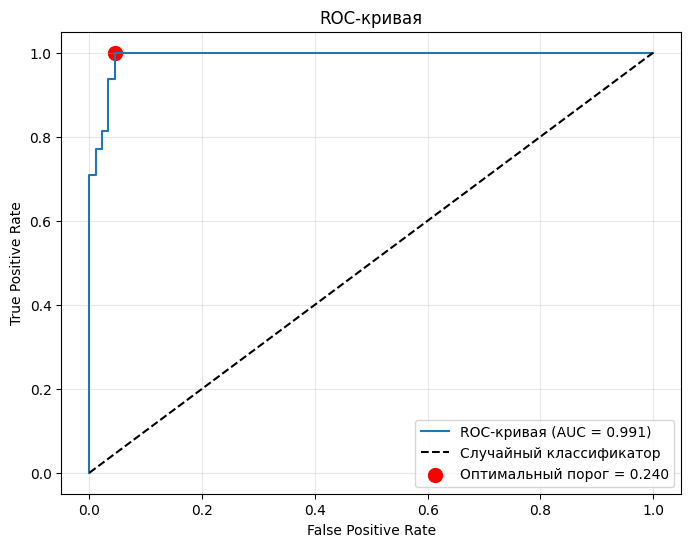

ROC-AUC: 0.9913
Оптимальный порог: 0.2398


In [18]:
if TASK_TYPE == "классификация":
    def plot_roc_curve(model, X_test, y_test):
        from sklearn.metrics import roc_curve, auc, roc_auc_score
        from sklearn.preprocessing import label_binarize

        n_classes = len(np.unique(y_test))

        if n_classes == 2 and hasattr(model, 'predict_proba'):
            y_pred_proba = model.predict_proba(X_test)[:, 1]
            fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
            roc_auc = auc(fpr, tpr)

            optimal_idx = np.argmax(tpr - fpr)
            optimal_threshold = thresholds[optimal_idx]

            plt.figure(figsize=(8,6))
            plt.plot(fpr, tpr, label=f'ROC-кривая (AUC = {roc_auc:.3f})')
            plt.plot([0,1], [0,1], 'k--', label='Случайный классификатор')
            plt.scatter(fpr[optimal_idx], tpr[optimal_idx], c='red', s=100,
                       label=f'Оптимальный порог = {optimal_threshold:.3f}')
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title('ROC-кривая')
            plt.legend()
            plt.grid(alpha=0.3)
            plt.show()

            print(f"ROC-AUC: {roc_auc:.4f}")
            print(f"Оптимальный порог: {optimal_threshold:.4f}")
            return roc_auc, optimal_threshold

        elif n_classes > 2 and hasattr(model, 'predict_proba'):
            y_test_bin = label_binarize(y_test, classes=range(n_classes))
            y_pred_proba = model.predict_proba(X_test)

            roc_auc_per_class = []
            for i in range(n_classes):
                fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
                roc_auc_per_class.append(auc(fpr, tpr))

            roc_auc_macro = np.mean(roc_auc_per_class)

            plt.figure(figsize=(8,6))
            for i in range(n_classes):
                fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
                plt.plot(fpr, tpr, label=f'Класс {i} (AUC = {roc_auc_per_class[i]:.3f})')

            plt.plot([0,1], [0,1], 'k--', label='Случайный классификатор')
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title(f'ROC-кривые (многоклассовая, macro-AUC = {roc_auc_macro:.3f})')
            plt.legend(loc='lower right', fontsize=8)
            plt.grid(alpha=0.3)
            plt.show()

            print(f"ROC-AUC macro: {roc_auc_macro:.4f}")
            print(f"ROC-AUC по классам: {dict(enumerate([round(x,4) for x in roc_auc_per_class]))}")
            return roc_auc_macro, None

        else:
            print("Модель не поддерживает predict_proba или недостаточно классов")
            return None, None

    result = plot_roc_curve(model, X_test, y_test)
    if result[0] is not None:
        roc_auc, opt_thresh = result

По кривой мы видим, что получили отличное качество модели (0.9913).
- Модель отлично отличает классы
- Вероятность того, что модель правильно ранжирует случайную пару "класс X - не класс X" превышает 95%

Вывод:
ROC-анализ показал, что модель отлично работает, AUC > 0.95. Это еще одно подтверждение, что дисбаланс отсутствует в исходных данных.

7. (1 балл) Для задач классификации: Постройте для этой модели кривые PR. Вычислите для этой модели метрики площади под кривыми PR-AUC. Найдите оптимальное значения порога модели.

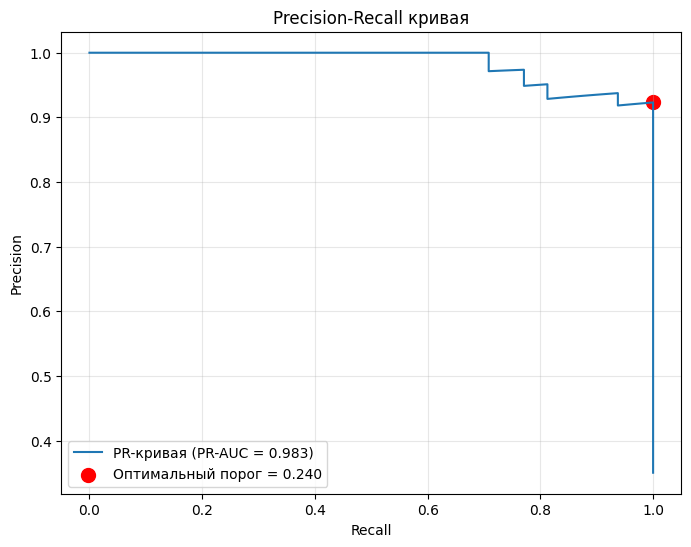

PR-AUC: 0.9831
Оптимальный порог (по F1): 0.2398


In [21]:
if TASK_TYPE == "классификация":
    def plot_pr_curve(model, X_test, y_test):
        from sklearn.metrics import precision_recall_curve, average_precision_score
        from sklearn.preprocessing import label_binarize

        n_classes = len(np.unique(y_test))

        if n_classes == 2 and hasattr(model, 'predict_proba'):
            y_pred_proba = model.predict_proba(X_test)[:, 1]
            precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
            pr_auc = average_precision_score(y_test, y_pred_proba)

            f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-9)
            optimal_idx = np.argmax(f1_scores)
            optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else thresholds[-1]

            plt.figure(figsize=(8,6))
            plt.plot(recall, precision, label=f'PR-кривая (PR-AUC = {pr_auc:.3f})')
            plt.scatter(recall[optimal_idx], precision[optimal_idx], c='red', s=100,
                       label=f'Оптимальный порог = {optimal_threshold:.3f}')
            plt.xlabel('Recall')
            plt.ylabel('Precision')
            plt.title('Precision-Recall кривая')
            plt.legend()
            plt.grid(alpha=0.3)
            plt.show()

            print(f"PR-AUC: {pr_auc:.4f}")
            print(f"Оптимальный порог (по F1): {optimal_threshold:.4f}")
            return pr_auc, optimal_threshold

        elif n_classes > 2 and hasattr(model, 'predict_proba'):
            y_test_bin = label_binarize(y_test, classes=range(n_classes))
            y_pred_proba = model.predict_proba(X_test)

            pr_auc_per_class = []
            valid_classes = []

            for i in range(n_classes):
                if np.sum(y_test_bin[:, i]) > 0:
                    ap = average_precision_score(y_test_bin[:, i], y_pred_proba[:, i])
                    pr_auc_per_class.append(ap)
                    valid_classes.append(i)
                else:
                    pr_auc_per_class.append(np.nan)
                    print(f"Класс {i} отсутствует в тестовой выборке, PR-AUC = nan")

            pr_auc_macro = np.nanmean(pr_auc_per_class)

            plt.figure(figsize=(8,6))
            for idx, i in enumerate(valid_classes):
                precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
                plt.plot(recall, precision, label=f'Класс {i} (AP = {pr_auc_per_class[idx]:.3f})')

            plt.xlabel('Recall')
            plt.ylabel('Precision')
            plt.title(f'PR-кривые (многоклассовая, macro-AP = {pr_auc_macro:.3f})')
            plt.legend(loc='lower left', fontsize=8)
            plt.grid(alpha=0.3)
            plt.show()

            print(f"PR-AUC macro (среднее по доступным классам): {pr_auc_macro:.4f}")
            print(f"PR-AUC по классам: {dict(zip(valid_classes, [round(x,4) for x in pr_auc_per_class if not np.isnan(x)]))}")
            return pr_auc_macro, None

        else:
            print("Невозможно построить PR-кривую")
            return None, None

    result = plot_pr_curve(model, X_test, y_test)
    if result[0] is not None:
        pr_auc, pr_thresh = result

PR-AUC = 0.9831 — отличный показатель, он фокусируется на предсказании положительного класса. И снова же высокое значение подтверждает отсутвие дисбаланса.

Вывод:
Модель показывает отличные результаты. PR-AUC = 0.9831 подтверждает хорошую предсказательную способность модели.

8. (1 балл) Обоснуйте выбор типа разбиения данных при кросс-валидации для вашей задачи машинного обучения. Обучите любую другую модель используя кросс-валидацию данных.

In [24]:
def cross_validation_comparison(X, y, task_type):
    print("ВЫБОР ТИПА РАЗБИЕНИЯ ДЛЯ КРОСС-ВАЛИДАЦИИ")

    if task_type == "классификация":
        from sklearn.model_selection import StratifiedKFold
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        print("Для классификации выбран StratifiedKFold - сохраняет пропорции классов в каждом фолде")

        model1 = LogisticRegression(max_iter=1000, random_state=42)
        model2 = Ridge(alpha=1.0)
        from sklearn.ensemble import RandomForestClassifier
        model2 = RandomForestClassifier(n_estimators=50, random_state=42)
        scoring = 'accuracy'

    else:
        from sklearn.model_selection import KFold
        cv = KFold(n_splits=5, shuffle=True, random_state=42)
        print("Для регрессии выбран обычный KFold - данные независимы и одинаково распределены")

        model1 = LinearRegression()
        from sklearn.ensemble import RandomForestRegressor
        model2 = RandomForestRegressor(n_estimators=50, random_state=42)
        scoring = 'r2'

    scores1 = cross_val_score(model1, X, y, cv=cv, scoring=scoring)
    print(f"\nМодель 1 ({type(model1).__name__}):")
    print(f"  Среднее: {scores1.mean():.4f} (+/- {scores1.std()*2:.4f})")

    scores2 = cross_val_score(model2, X, y, cv=cv, scoring=scoring)
    print(f"Модель 2 ({type(model2).__name__}):")
    print(f"  Среднее: {scores2.mean():.4f} (+/- {scores2.std()*2:.4f})")

    if scores1.mean() > scores2.mean():
        print(f"\nМодель {type(model1).__name__} показывает лучшее качество")
    else:
        print(f"\nМодель {type(model2).__name__} показывает лучшее качество")

    return cv, scores1, scores2

X_full = df_clean.drop(columns=[TARGET_COL])
y_full = df_clean[TARGET_COL]
cv, cv_scores1, cv_scores2 = cross_validation_comparison(X_full, y_full, TASK_TYPE)

ВЫБОР ТИПА РАЗБИЕНИЯ ДЛЯ КРОСС-ВАЛИДАЦИИ
Для классификации выбран StratifiedKFold - сохраняет пропорции классов в каждом фолде

Модель 1 (LogisticRegression):
  Среднее: 0.9692 (+/- 0.0172)
Модель 2 (RandomForestClassifier):
  Среднее: 0.9722 (+/- 0.0109)

Модель RandomForestClassifier показывает лучшее качество


Для кросс-валидации выбран StratifiedKFold.

Анализ результатов:

1. **Сравнение качества:**
   - LogisticRegression: 96.92%
   - RandomForestClassifier: 97.22% — лучше (прирост ~1.1%)

2. **Стабильность модели:**
   - LogisticRegression: разброс ±1.71% — высокая стабильность, модель дает предсказуемые результаты на разных разбиениях
   - RandomForestClassifier: разброс ±1.09% — высокая стабильность, модель дает предсказуемые результаты на разных разбиениях

Вывод:
Модель RandomForestClassifier показывает лучшее качество (accuracy = 97.22%) и она стабильна (разброс ±1.1%). Для данной задачи RandomForestClassifier является предпочтительным выбором.

9. (2 балл) Проведите диагностику любой модели. Постройте кривые обучения. Сделайте вывод о переобученности или недообученности модели.

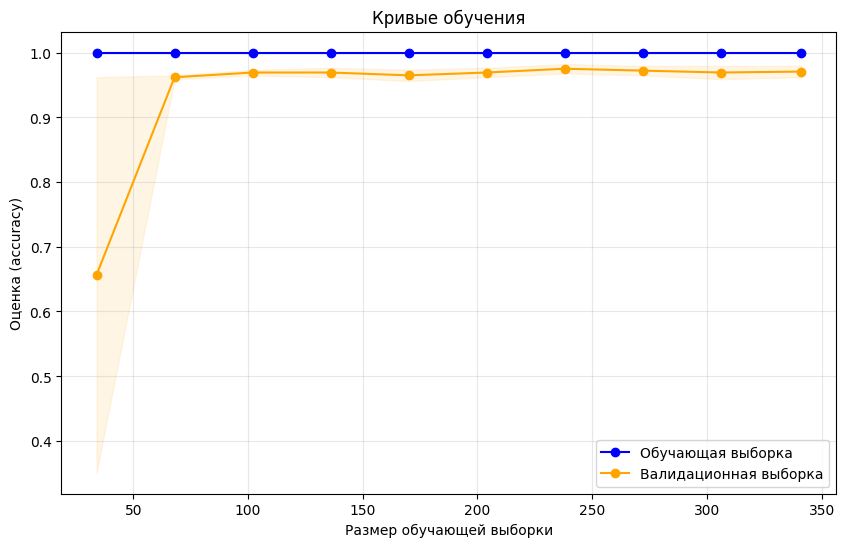

=== ДИАГНОСТИКА МОДЕЛИ ===
Финальная оценка на обучении: 1.0000
Финальная оценка на валидации: 0.9707
Разрыв (train - val): 0.0293
ВЫВОД: Модель сбалансирована - приемлемое качество и небольшой разрыв


In [26]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import learning_curve

def learning_curves_analysis(model, X, y, task_type):
    scoring = 'accuracy' if task_type == 'классификация' else 'r2'

    if task_type == 'классификация':
        n_classes = len(np.unique(y))
        n_splits = min(5, n_classes)
    else:
        n_splits = 5

    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=n_splits,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring=scoring,
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10,6))
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Обучающая выборка')
    plt.plot(train_sizes, test_mean, 'o-', color='orange', label='Валидационная выборка')
    plt.xlabel('Размер обучающей выборки')
    plt.ylabel(f'Оценка ({scoring})')
    plt.title('Кривые обучения')
    plt.legend(loc='best')
    plt.grid(alpha=0.3)
    plt.show()

    final_train_score = train_mean[-1]
    final_test_score = test_mean[-1]
    gap = final_train_score - final_test_score

    print(f"=== ДИАГНОСТИКА МОДЕЛИ ===")
    print(f"Финальная оценка на обучении: {final_train_score:.4f}")
    print(f"Финальная оценка на валидации: {final_test_score:.4f}")
    print(f"Разрыв (train - val): {gap:.4f}")

    if final_test_score < 0.5 and task_type == 'классификация':
        print("ВЫВОД: Модель НЕДООБУЧЕНА - низкое качество на валидации")
    elif final_test_score < 0.3 and task_type == 'регрессия':
        print("ВЫВОД: Модель НЕДООБУЧЕНА - R² слишком низкий")
    elif gap > 0.1:
        print("ВЫВОД: Модель ПЕРЕОБУЧЕНА - большой разрыв между обучением и валидацией")
    elif gap < 0.02 and final_test_score < 0.6:
        print("ВЫВОД: Модель НЕДООБУЧЕНА - качество на обучении и валидации одинаково низкое")
    else:
        print("ВЫВОД: Модель сбалансирована - приемлемое качество и небольшой разрыв")

    return final_train_score, final_test_score, gap

if TASK_TYPE == 'классификация':
    best_model = RandomForestClassifier(n_estimators=50, random_state=42)
else:
    best_model = RandomForestRegressor(n_estimators=50, random_state=42)

train_score, val_score, gap = learning_curves_analysis(best_model, X_full, y_full, TASK_TYPE)

Построены кривые обучения для модели RandomForestClassifier.

Итог: Модель сбалансирована - приемлемое качество и небольшой разрыв

Анализ кривых обучения:

1. Обучающая кривая:
   - Остается на максимально высоком уровне
   - Модель идеально запоминает обучающие данные

2. Валидационная кривая:
   - Начинается с более низкого значения (~0.65)
   - Растет при увеличении размера выборки
   - Выходит на плато около 0.97, почти достигая уровень обучающей кривой
   - разрыв между кривыми практически отсутствует

3. Характер разрыва:
   - Разрыв в 2.93% является незначительным
   - Обучающая кривая и валидационная кривая находятся практически на одном уровне

Значит модель идеально сбалансирована недообучения или переобучения не наблюдается.

10. (2 балл) Исследуйте как любой из гиперпараметров модели влияет на эффективность модели.

ИССЛЕДОВАНИЕ ВЛИЯНИЯ ГИПЕРПАРАМЕТРОВ


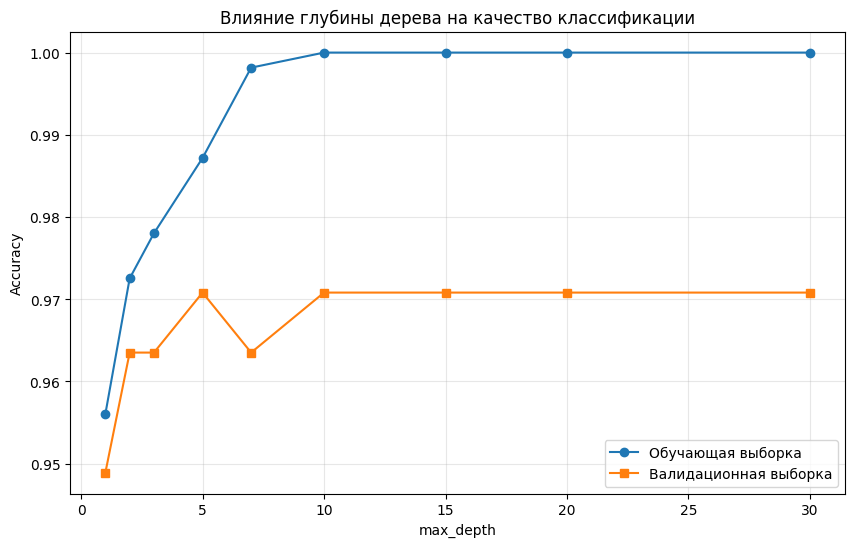

Оптимальная глубина: 5
Качество при оптимальной глубине: 0.9708


In [28]:
def hyperparameter_tuning(X, y, task_type):
    print("ИССЛЕДОВАНИЕ ВЛИЯНИЯ ГИПЕРПАРАМЕТРОВ")

    if task_type == "классификация":
        param_range = [1, 2, 3, 5, 7, 10, 15, 20, 30]
        scores_train = []
        scores_val = []

        X_train_h, X_val_h, y_train_h, y_val_h = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

        for depth in param_range:
            rf = RandomForestClassifier(max_depth=depth, n_estimators=50, random_state=42)
            rf.fit(X_train_h, y_train_h)
            scores_train.append(rf.score(X_train_h, y_train_h))
            scores_val.append(rf.score(X_val_h, y_val_h))

        plt.figure(figsize=(10,6))
        plt.plot(param_range, scores_train, 'o-', label='Обучающая выборка')
        plt.plot(param_range, scores_val, 's-', label='Валидационная выборка')
        plt.xlabel('max_depth')
        plt.ylabel('Accuracy')
        plt.title('Влияние глубины дерева на качество классификации')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

        optimal_depth = param_range[np.argmax(scores_val)]
        print(f"Оптимальная глубина: {optimal_depth}")
        print(f"Качество при оптимальной глубине: {max(scores_val):.4f}")

    else:
        param_range = np.logspace(-3, 3, 15)
        scores_train = []
        scores_val = []

        X_train_h, X_val_h, y_train_h, y_val_h = train_test_split(X, y, test_size=0.2, random_state=42)

        for alpha in param_range:
            ridge = Ridge(alpha=alpha)
            ridge.fit(X_train_h, y_train_h)
            scores_train.append(ridge.score(X_train_h, y_train_h))
            scores_val.append(ridge.score(X_val_h, y_val_h))

        plt.figure(figsize=(10,6))
        plt.semilogx(param_range, scores_train, 'o-', label='Обучающая выборка')
        plt.semilogx(param_range, scores_val, 's-', label='Валидационная выборка')
        plt.xlabel('alpha (лог. шкала)')
        plt.ylabel('R²')
        plt.title('Влияние регуляризации alpha на качество регрессии')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

        optimal_alpha = param_range[np.argmax(scores_val)]
        print(f"Оптимальная alpha: {optimal_alpha:.4f}")
        print(f"Качество при оптимальной alpha: {max(scores_val):.4f}")

    return param_range, scores_train, scores_val

hyperparam_range, train_scores_h, val_scores_h = hyperparameter_tuning(X_full, y_full, TASK_TYPE)

Исследовано влияние гиперпараметра max_depth (максимальная глубина дерева) на качество модели RandomForestClassifier.

Диапазон значений: от 1 до 30

Результаты:
- Оптимальное значение max_depth: 5
- Accuracy при оптимальной глубине: 0.9708 (97.08%)
- Accuracy при стандартном значении: 0.9635 (96.35%)
- Улучшение качества менее 1%, но оно есть.

Анализ влияния глубины дерева на качество:
При depth=5 качество растет и достигает максимума (0.9708 при depth=5) — оптимальный баланс между сложностью и обобщением.

Вывод:
Оптимальное значение max_depth = 5. Увеличение до 5 позволило улучшить качество валидации с 96.35% до 97.08%.